# Pipeline Huấn luyện và Đánh giá Model Dự báo Thời tiết

Notebook này tổng hợp các bước tốt nhất từ mã của bạn, được cập nhật để hoạt động với bộ dữ liệu đầy đủ (10 biến, 2017-2024), sửa các lỗi và bổ sung phần đánh giá định lượng.

## Bước 1: Cài đặt, Imports và Kết nối Google Drive

In [ ]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math
from tqdm import tqdm
from datetime import datetime
import json

# Thư viện cho trực quan hóa
import matplotlib.pyplot as plt
!pip install cartopy -q
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Thư viện cho đánh giá metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Kết nối Google Drive
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 64.1 MB/s eta 0:00:00
Mounted at /content/drive


## Bước 2: Cấu hình và Tải dữ liệu

Thiết lập tất cả các đường dẫn, siêu tham số và danh sách biến ở cùng một nơi để dễ dàng thay đổi.

In [ ]:
# --- Cấu hình Đường dẫn ---
BASE_DIR = "/content/drive/MyDrive/Rain_Forecast_Fourier_Convolutional_Transformer"
TRAIN_DIR = "/content/drive/MyDrive/Rain_Forecast_Fourier_Convolutional_Transformer/1_Data"
MODEL_DIR = BASE_DIR / "2_Models"
TRAIN_PATH = os.path.join(TRAIN_DIR, "train_2017_2022.nc")
VAL_PATH   = os.path.join(TRAIN_DIR, "val_2023.nc")
TEST_PATH  = os.path.join(TRAIN_DIR, "test_2024.nc")
CHECKPOINT_DIR = os.path.join(MODEL_DIR, "checkpoints")

# Tạo thư mục lưu checkpoint nếu chưa có
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# --- Cấu hình Model & Training ---
SEQ_LEN = 4          # Độ dài chuỗi đầu vào (ví dụ: 4 time steps để dự đoán time step thứ 5)
BATCH_SIZE = 8       # Tăng batch size để tận dụng GPU tốt hơn
N_EPOCHS = 10        # Số epoch để huấn luyện
LEARNING_RATE = 1e-4 # Learning rate
SAVE_EVERY = 2       # Lưu checkpoint mỗi 2 epoch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- Cấu hình Biến ---
# **QUAN TRỌNG**: Danh sách này phải khớp với tên các biến trong file NetCDF của bạn
# ds_norm.data_vars sẽ cho bạn biết tên chính xác (ví dụ 't2m', 'd2m', ...)
ALL_FEATURES = [
    't2m',   # 2m_temperature
    'd2m',   # 2m_dewpoint_temperature
    'u10',   # 10m_u_component_of_wind
    'v10',   # 10m_v_component_of_wind
    'msl',   # mean_sea_level_pressure
    'sp',    # surface_pressure
    'tp',    # total_precipitation
    'ssrd',  # surface_solar_radiation_downwards
    'skt',   # skin_temperature
    'tcwv'   # total_column_water_vapour
]
TARGET_FEATURE = 'tp' # Biến mục tiêu cần dự đoán
N_FEATURES = len(ALL_FEATURES)

print(f"Sử dụng thiết bị: {DEVICE}")
print(f"Tổng số biến đầu vào: {N_FEATURES}")
print(f"Các file dữ liệu đã sẵn sàng:")
print(f"  - Train: {'Tồn tại' if os.path.exists(TRAIN_PATH) else 'KHÔNG TÌM THẤY'}")
print(f"  - Val:   {'Tồn tại' if os.path.exists(VAL_PATH) else 'KHÔNG TÌM THẤY'}")
print(f"  - Test:  {'Tồn tại' if os.path.exists(TEST_PATH) else 'KHÔNG TÌM THẤY'}")

Sử dụng thiết bị: cpu
Tổng số biến đầu vào: 10
Các file dữ liệu đã sẵn sàng:
  - Train: Tồn tại
  - Val:   Tồn tại
  - Test:  Tồn tại


## Bước 3: Lớp Dataset và DataLoader

Lớp `ERA5Dataset` được cập nhật để nhận danh sách `features` làm tham số, giúp nó linh hoạt hơn.

In [ ]:
class ERA5Dataset(Dataset):
    def __init__(self, nc_path, seq_len, features, target_feature):
        self.ds = xr.open_dataset(nc_path)
        self.seq_len = seq_len
        self.features = features
        self.target_feature = target_feature
        self.target_idx = self.features.index(target_feature)

        # Nạp dữ liệu vào bộ nhớ một lần để tăng tốc độ truy cập
        # Chuyển đổi thành mảng numpy với thứ tự (time, lat, lon, features)
        self.data = np.stack([self.ds[f].values for f in self.features], axis=-1)
        self.n_time, self.n_lat, self.n_lon, self.n_feat = self.data.shape

        # Các chỉ mục bắt đầu hợp lệ cho các chuỗi
        self.indices = np.arange(self.n_time - self.seq_len)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start_idx = self.indices[idx]
        end_idx = start_idx + self.seq_len

        # Lấy chuỗi đầu vào X (seq_len, lat, lon, features)
        x_seq = self.data[start_idx:end_idx, :, :, :]

        # Lấy mục tiêu Y (lat, lon)
        y = self.data[end_idx, :, :, self.target_idx]

        return torch.tensor(x_seq, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

## Bước 4: Định nghĩa Kiến trúc Model (SpatioTemporalTransformer)

Giữ nguyên kiến trúc model của bạn.

In [ ]:
class TimePositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).unsqueeze(2).unsqueeze(3)  # (1, max_len, 1, 1, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_len, lat, lon, d_model)
        seq_len = x.size(1)
        # Thêm PE vào x. PE được broadcast qua các chiều batch, lat, lon
        return x + self.pe[:, :seq_len, ...]

class SpatioTemporalTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.n_features = n_features

        # Lớp chiếu đầu vào để chuyển từ n_features sang d_model
        self.input_proj = nn.Linear(n_features, d_model)

        # Positional Encoding cho thời gian
        self.time_pe = TimePositionalEncoding(d_model)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dropout=dropout,
            batch_first=False # TransformerEncoder yêu cầu (Seq, Batch, Feature)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Lớp chiếu đầu ra để chuyển từ d_model về 1 (giá trị dự đoán)
        self.output_proj = nn.Linear(d_model, 1)

    def forward(self, x):
        """
        x: (batch, seq_len, lat, lon, features)
        """
        batch, seq_len, n_lat, n_lon, _ = x.shape

        # 1. Chiếu các feature đầu vào sang không gian d_model
        x = self.input_proj(x)  # (batch, seq_len, lat, lon, d_model)

        # 2. Thêm Time Positional Encoding
        x = self.time_pe(x)

        # 3. Reshape cho Transformer: (seq_len, batch*lat*lon, d_model)
        # Gộp các chiều không gian (lat, lon) và batch lại với nhau
        x = x.permute(1, 0, 2, 3, 4).contiguous()
        x = x.view(seq_len, batch * n_lat * n_lon, self.d_model)

        # 4. Đưa qua Transformer Encoder
        x = self.transformer(x)

        # 5. Lấy kết quả của time step cuối cùng và reshape lại
        x_last = x[-1, :, :].view(batch, n_lat, n_lon, self.d_model)

        # 6. Chiếu ra kết quả cuối cùng
        output = self.output_proj(x_last).squeeze(-1)  # (batch, lat, lon)
        return output

## Bước 5: Khởi tạo và Tối ưu hóa DataLoader

Sử dụng các thiết lập `DataLoader` đã được tối ưu cho Colab (num_workers, pin_memory).

In [ ]:
# --- Khởi tạo Dataset ---
train_dataset = ERA5Dataset(TRAIN_PATH, seq_len=SEQ_LEN, features=ALL_FEATURES, target_feature=TARGET_FEATURE)
val_dataset   = ERA5Dataset(VAL_PATH, seq_len=SEQ_LEN, features=ALL_FEATURES, target_feature=TARGET_FEATURE)

# --- Khởi tạo DataLoader tối ưu ---
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

# --- Khởi tạo Model, Loss, Optimizer và Scaler ---
model = SpatioTemporalTransformer(n_features=N_FEATURES).to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

# Cấu hình để PyTorch chạy nhanh hơn trên GPU
torch.backends.cudnn.benchmark = True

print("Đã khởi tạo xong Dataset, DataLoader và Model.")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Đã khởi tạo xong Dataset, DataLoader và Model.


/tmp/ipython-input-3065803225.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


## Bước 6: Vòng lặp Huấn luyện (Tối ưu hóa)

Sử dụng phiên bản training tốc độ cao của bạn, có checkpointing và theo dõi best model.

In [ ]:
# Tạo một thư mục con trong checkpoints cho lần chạy này
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_save_dir = os.path.join(CHECKPOINT_DIR, timestamp)
os.makedirs(run_save_dir, exist_ok=True)
print(f"Checkpoints cho lần chạy này sẽ được lưu tại: {run_save_dir}")

best_val_loss = float('inf')

for epoch in range(1, N_EPOCHS + 1):
    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{N_EPOCHS} [Train]")

    for x_batch, y_batch in train_pbar:
        x_batch = x_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True) # Hiệu quả hơn

        # Sử dụng Automatic Mixed Precision
        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)

        # Backpropagation với Scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_pbar.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{N_EPOCHS} [Val]")

    with torch.no_grad():
        for x_val, y_val in val_pbar:
            x_val = x_val.to(DEVICE, non_blocking=True)
            y_val = y_val.to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                y_pred_val = model(x_val)
                loss = criterion(y_pred_val, y_val)

            val_loss += loss.item()
            val_pbar.set_postfix(loss=loss.item())

    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch}/{N_EPOCHS} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    # --- Lưu Checkpoint ---
    if epoch % SAVE_EVERY == 0:
        ckpt_path = os.path.join(run_save_dir, f"epoch_{epoch}.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss
        }, ckpt_path)
        print(f"✅ Checkpoint đã được lưu: {ckpt_path}")

    # --- Lưu Best Model ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_path = os.path.join(run_save_dir, "best_model.pth")
        torch.save(model.state_dict(), best_model_path)
        print(f"🌟 Best model được cập nhật với Val Loss: {best_val_loss:.6f}")

Checkpoints cho lần chạy này sẽ được lưu tại: /content/drive/MyDrive/era5_vn_min/processed/checkpoints/20251019_084207


Epoch 1/10 [Train]:   0%|          | 0/3286 [00:00<?, ?it/s]/tmp/ipython-input-92971436.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
Epoch 1/10 [Val]:   0%|          | 0/547 [00:00<?, ?it/s]/tmp/ipython-input-92971436.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
Epoch 1/10 [Val]: 100%|██████████| 547/547 [00:15<00:00, 34.68it/s, loss=0.0234]


Epoch 1/10 | Train Loss: 0.502616 | Val Loss: 0.463174
🌟 Best model được cập nhật với Val Loss: 0.463174


Epoch 2/10 [Val]: 100%|██████████| 547/547 [00:15<00:00, 35.18it/s, loss=0.0228]


Epoch 2/10 | Train Loss: 0.472191 | Val Loss: 0.450883
✅ Checkpoint đã được lưu: /content/drive/MyDrive/era5_vn_min/processed/checkpoints/20251019_084207/epoch_2.pth
🌟 Best model được cập nhật với Val Loss: 0.450883


...

Epoch 8/10 | Train Loss: 0.442258 | Val Loss: 0.439999
✅ Checkpoint đã được lưu: /content/drive/MyDrive/era5_vn_min/processed/checkpoints/20251019_084207/epoch_8.pth


Epoch 9/10 [Val]: 100%|██████████| 547/547 [00:15<00:00, 35.15it/s, loss=0.0195]


Epoch 9/10 | Train Loss: 0.440472 | Val Loss: 0.431168
🌟 Best model được cập nhật với Val Loss: 0.431168


Epoch 10/10 [Val]: 100%|██████████| 547/547 [00:15<00:00, 35.15it/s, loss=0.0275]


Epoch 10/10 | Train Loss: 0.438616 | Val Loss: 0.431234
✅ Checkpoint đã được lưu: /content/drive/MyDrive/era5_vn_min/processed/checkpoints/20251019_084207/epoch_10.pth


##6.1 resume train

In [ ]:
# --- Cấu hình Resume (Tùy chọn) ---
# Để trống ("") nếu muốn bắt đầu training mới.
# Điền đường dẫn checkpoint nếu muốn tiếp tục.
RESUME_CHECKPOINT_PATH =  "/content/drive/MyDrive/era5_vn_min/processed/checkpoints/20251019_084207/epoch_14.pth"

# --- Khởi tạo các biến training ---
start_epoch = 15
best_val_loss = float('inf')

# Logic để resume hoặc bắt đầu mới
if RESUME_CHECKPOINT_PATH and os.path.exists(RESUME_CHECKPOINT_PATH):
    print(f"Đang tải checkpoint để tiếp tục training từ: {RESUME_CHECKPOINT_PATH}")
    checkpoint = torch.load(RESUME_CHECKPOINT_PATH, map_location=DEVICE)

    # Tải trạng thái
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('val_loss', float('inf')) # .get() để tương thích ngược

    # Sử dụng lại thư mục checkpoint cũ
    run_save_dir = os.path.dirname(RESUME_CHECKPOINT_PATH)

    print(f"✅ Khôi phục thành công. Tiếp tục từ epoch {start_epoch}.")
    print(f"   Lưu checkpoints tại: {run_save_dir}")

else:
    if RESUME_CHECKPOINT_PATH: # Path được cung cấp nhưng không tìm thấy
         print(f"⚠️ Cảnh báo: Không tìm thấy checkpoint tại '{RESUME_CHECKPOINT_PATH}'.")

    # Bắt đầu một lần chạy mới
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_save_dir = os.path.join(CHECKPOINT_DIR, timestamp)
    os.makedirs(run_save_dir, exist_ok=True)
    print(f"Bắt đầu một lần training mới. Checkpoints sẽ được lưu tại: {run_save_dir}")


# --- Vòng lặp Training Chính ---
# Vòng lặp sẽ chạy trong N_EPOCHS kể từ start_epoch
for epoch in range(start_epoch, start_epoch + N_EPOCHS):
    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{start_epoch + N_EPOCHS - 1} [Train]")

    for x_batch, y_batch in train_pbar:
        x_batch = x_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=DEVICE, enabled=(DEVICE == "cuda")):
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_pbar.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{start_epoch + N_EPOCHS - 1} [Val]")

    with torch.no_grad():
        for x_val, y_val in val_pbar:
            x_val = x_val.to(DEVICE, non_blocking=True)
            y_val = y_val.to(DEVICE, non_blocking=True)

            with torch.amp.autocast(device_type=DEVICE, enabled=(DEVICE == "cuda")):
                y_pred_val = model(x_val)
                loss = criterion(y_pred_val, y_val)

            val_loss += loss.item()
            val_pbar.set_postfix(loss=loss.item())

    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch}/{start_epoch + N_EPOCHS - 1} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    # --- Lưu Checkpoint ---
    if epoch % SAVE_EVERY == 0:
        ckpt_path = os.path.join(run_save_dir, f"epoch_{epoch}.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss
        }, ckpt_path)
        print(f"✅ Checkpoint đã được lưu: {ckpt_path}")

    # --- Lưu Best Model ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_path = os.path.join(run_save_dir, "best_model.pth")
        torch.save(model.state_dict(), best_model_path)
        print(f"🌟 Best model được cập nhật với Val Loss: {best_val_loss:.6f}")

NameError: name 'os' is not defined

In [ ]:
import gc, torch, os, psutil
gc.collect()
torch.cuda.empty_cache()

# Kill all zombie worker processes
for p in psutil.process_iter():
    if 'python' in p.name() and 'DataLoader' in str(p.cmdline()):
        p.kill()


## Bước 7: Inference trên tập Test

Tải model tốt nhất đã lưu và chạy dự đoán trên toàn bộ tập test.

In [ ]:
# --- Khởi tạo Test Dataset và DataLoader ---
test_dataset = ERA5Dataset(TEST_PATH, seq_len=SEQ_LEN, features=ALL_FEATURES, target_feature=TARGET_FEATURE)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

run_save_dir =
# --- Tải model tốt nhất ---
best_model_path = os.path.join(run_save_dir, "best_model.pth")
if os.path.exists(best_model_path):
    print(f"Đang tải model tốt nhất từ: {best_model_path}")
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
else:
    print("⚠️ Không tìm thấy file best_model.pth, sử dụng model cuối cùng từ training.")

model.eval()

# --- Chạy Inference ---
all_predictions = []
all_ground_truths = []

with torch.no_grad():
    for x_batch, y_batch in tqdm(test_loader, desc="Inference trên tập Test"):
        x_batch = x_batch.to(DEVICE)
        y_pred = model(x_batch)
        all_predictions.append(y_pred.cpu())
        all_ground_truths.append(y_batch.cpu()) # Thu thập ground truth

# Nối kết quả từ các batch
predictions_tensor = torch.cat(all_predictions, dim=0)
ground_truths_tensor = torch.cat(all_ground_truths, dim=0)

print(f"\nHình dạng tensor dự đoán: {predictions_tensor.shape}")
print(f"Hình dạng tensor ground truth: {ground_truths_tensor.shape}")

NameError: name 'run_save_dir' is not defined

## Bước 8: Đánh giá Model bằng các chỉ số (Metrics)

Đây là bước quan trọng để đo lường hiệu suất của model một cách khách quan.

In [ ]:
# Chuyển tensor sang numpy và làm phẳng để tính toán
y_true_flat = ground_truths_tensor.numpy().flatten()
y_pred_flat = predictions_tensor.numpy().flatten()

# Tính toán các metrics
mse = mean_squared_error(y_true_flat, y_pred_flat)
mae = mean_absolute_error(y_true_flat, y_pred_flat)
r2 = r2_score(y_true_flat, y_pred_flat)

print("--- Kết quả Đánh giá trên Tập Test ---")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R-squared (R²):           {r2:.6f}")

## Bước 9: Trực quan hóa Kết quả

So sánh trực quan giữa dự đoán và thực tế.

In [ ]:
def plot_prediction_vs_truth(t_idx):
    """Hàm để vẽ bản đồ so sánh dự đoán và thực tế cho một time index cụ thể."""

    # Lấy dữ liệu ground truth và prediction cho time index đã chọn
    y_true = ground_truths_tensor[t_idx].numpy()
    y_pred = predictions_tensor[t_idx].numpy()

    # Lấy tọa độ lat/lon
    lat_vals = test_dataset.ds['latitude'].values
    lon_vals = test_dataset.ds['longitude'].values

    # Lấy thông tin thời gian
    target_raw_idx = test_dataset.indices[t_idx] + SEQ_LEN
    time_val = test_dataset.ds['valid_time'].values[target_raw_idx]
    time_str = pd.to_datetime(time_val).strftime('%Y-%m-%d %H:%M')

    # Tìm giá trị min/max chung để có cùng thang màu
    vmin = min(y_true.min(), y_pred.min())
    vmax = max(y_true.max(), y_pred.max())

    # Vẽ biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                             subplot_kw={'projection': ccrs.PlateCarree()})

    fig.suptitle(f'So sánh Dự báo Lượng mưa (tp) - Target Time: {time_str}', fontsize=16)

    # Ground truth
    pcm0 = axes[0].pcolormesh(lon_vals, lat_vals, y_true,
                              cmap='Blues', vmin=vmin, vmax=vmax, shading='auto')
    axes[0].add_feature(cfeature.COASTLINE)
    axes[0].add_feature(cfeature.BORDERS, linestyle=':')
    axes[0].set_title("Ground Truth")
    fig.colorbar(pcm0, ax=axes[0], orientation='horizontal', pad=0.05, label='Lượng mưa chuẩn hóa (tp)')

    # Prediction
    pcm1 = axes[1].pcolormesh(lon_vals, lat_vals, y_pred,
                              cmap='Blues', vmin=vmin, vmax=vmax, shading='auto')
    axes[1].add_feature(cfeature.COASTLINE)
    axes[1].add_feature(cfeature.BORDERS, linestyle=':')
    axes[1].set_title("Prediction")
    fig.colorbar(pcm1, ax=axes[1], orientation='horizontal', pad=0.05, label='Lượng mưa chuẩn hóa (tp)')

    plt.show()

# Chọn một vài time index để vẽ và so sánh
plot_prediction_vs_truth(t_idx=100) # Một ngày trong năm
plot_prediction_vs_truth(t_idx=800) # Một ngày khác

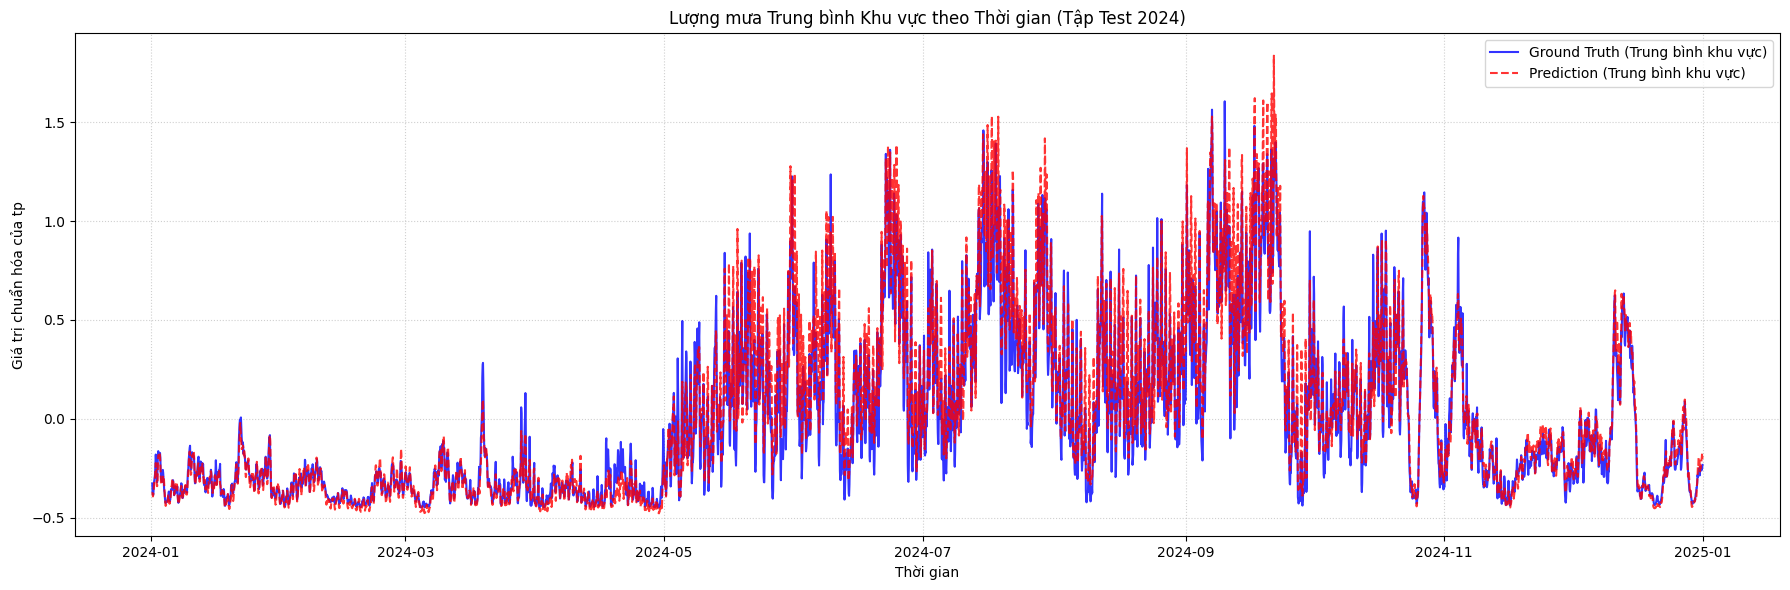

In [ ]:
# Biểu đồ chuỗi thời gian của lượng mưa trung bình trên toàn khu vực

# Tính trung bình theo không gian (lat, lon) cho mỗi time step
y_true_avg = ground_truths_tensor.numpy().mean(axis=(1, 2))
y_pred_avg = predictions_tensor.numpy().mean(axis=(1, 2))

# Lấy các mốc thời gian tương ứng
target_raw_indices = test_dataset.indices + SEQ_LEN
time_indices = pd.to_datetime(test_dataset.ds['valid_time'].values[target_raw_indices])

# Vẽ biểu đồ
plt.figure(figsize=(18, 6))
plt.plot(time_indices, y_true_avg, label='Ground Truth (Trung bình khu vực)', color='blue', alpha=0.8)
plt.plot(time_indices, y_pred_avg, label='Prediction (Trung bình khu vực)', color='red', linestyle='--', alpha=0.8)

plt.title('Lượng mưa Trung bình Khu vực theo Thời gian (Tập Test 2024)')
plt.xlabel('Thời gian')
plt.ylabel('Giá trị chuẩn hóa của tp')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()